# 1D Consolidation with L-BFGS

This notebook solves the same Terzaghi problem as 08c with a deeper network (five hidden layers
of 60 neurons, $\tanh$) and a single L-BFGS stage instead of Adam followed by L-BFGS. The loss
splits into a physics term $L_f$, the mean squared PDE residual at interior points, and a known
data term $L_k$, the mean squared error on the two boundary conditions and the initial
condition. The excess pore pressure is compared with Terzaghi's series solution at six values of
the time factor $T_v = c_v t / H^2$.

TODO: confirm the source reference. The architecture, the $L_f$/$L_k$ split and the L-BFGS
choice follow a paper cited in the earlier draft of this notebook as "Zhang et al. (2024)",
which could not be identified. The closest match found is Zhang, S., Lan, P., Li, H.-C.,
Tong, C.-X. and Sheng, D. (2022), "Physics-informed neural networks for consolidation of
soils", *Engineering Computations*, 39(7), 2845-2865, doi:10.1108/EC-08-2021-0492. Verify
before citing it in class.

By default the notebook loads the trained weights in `pinn_consolidation_model.pth`. Those
weights come from a 6000-epoch run on a GPU. Set `RETRAIN = True` to train again, which takes
hours on a CPU. That run recorded its loss history with an extra $1/n$ factor on every term,
which the loss functions below no longer carry, so the numbers on the training history plots
are smaller than the same losses computed with the code here by the number of points in each
term. Retraining regenerates both the weights and the history.

## Setup: network and derivatives

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
import time
import os
from tqdm import tqdm

# Set device (MPS for Apple Silicon, CUDA for NVIDIA, CPU as fallback)
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")
torch.manual_seed(42)

class OptimizedPINN(nn.Module):
    """Five hidden layers of 60 neurons with tanh, the architecture in the reference above."""

    def __init__(self, layers=[2, 60, 60, 60, 60, 60, 1]):
        super(OptimizedPINN, self).__init__()
        self.layers = nn.ModuleList()

        # Build the hidden layers
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

        # Xavier initialization
        self.init_weights()

    def init_weights(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        # Input: [z, t] in physical units, z in [0, H] and t in [0, T].
        # With H = T = 1 below both already sit in [0, 1]. A different H or T would
        # need an explicit rescaling here.
        for i, layer in enumerate(self.layers[:-1]):
            x = torch.tanh(layer(x))  # tanh is C^2, so the second derivative is not identically zero
        x = self.layers[-1](x)  # Linear output
        return x

def compute_derivatives(model, z, t):
    """Compute derivatives for PDE"""
    zt = torch.cat([z, t], dim=1)
    zt.requires_grad_(True)

    u = model(zt)

    # First derivatives
    grads = grad(u.sum(), zt, create_graph=True)[0]
    u_z = grads[:, 0:1]
    u_t = grads[:, 1:2]

    # Second derivative w.r.t. z
    u_zz = grad(u_z.sum(), zt, create_graph=True)[0][:, 0:1]

    return u, u_t, u_z, u_zz

Using device: mps


## Loss terms, analytical solution and collocation points

$L_f$ and $L_k$ are both plain mean squared errors. `torch.mean` already divides by the number
of points, so no further $1/n$ factor belongs here. Both are measured in kPa² and kPa²/m², and
the total loss is $L = L_k + L_f$ with unit weights.

In [2]:
def physics_loss_lf(model, z_interior, t_interior, cv):
    """Physics loss Lf: the mean squared PDE residual at the interior points."""
    u, u_t, u_z, u_zz = compute_derivatives(model, z_interior, t_interior)

    # PDE: ∂u/∂t = cv * ∂²u/∂z²
    pde_residual = u_t - cv * u_zz

    # Mean squared residual. torch.mean already divides by the number of points.
    Lf = torch.mean(pde_residual**2)

    return Lf

def known_data_loss_lk(model, z_bc, t_bc, z_bot, t_bot, z_ic, t_ic, u0):
    """Known data loss Lk: the two boundary conditions and the initial condition."""

    # Boundary condition: u(0,t) = 0 (top drainage)
    zt_bc = torch.cat([z_bc, t_bc], dim=1)
    u_bc = model(zt_bc)

    # Bottom boundary: ∂u/∂z(H,t) = 0
    u_bot, u_t_bot, u_z_bot, u_zz_bot = compute_derivatives(model, z_bot, t_bot)

    # Initial condition: u(z,0) = u0
    zt_ic = torch.cat([z_ic, t_ic], dim=1)
    u_ic = model(zt_ic)
    u0_tensor = torch.full_like(u_ic, u0)

    # Compute individual loss components
    bc_loss = torch.mean(u_bc**2)
    bottom_loss = torch.mean(u_z_bot**2)
    ic_loss = torch.mean((u_ic - u0_tensor)**2)

    # Combined Lk loss
    Lk = bc_loss + bottom_loss + ic_loss

    return Lk, bc_loss, bottom_loss, ic_loss

def analytical_solution(z, t, H, cv, u0, n_terms=100):
    """High-precision analytical solution"""
    u = np.zeros_like(z)
    for n in range(n_terms):
        m = 2*n + 1
        term = (4*u0/np.pi) * (np.sin(m*np.pi*z/(2*H))/m) * np.exp(-(m**2)*(np.pi**2)*cv*t/(4*H**2))
        u += term
        if np.max(np.abs(term)) < 1e-12:
            break
    return u

def generate_collocation_points(H, T, N_interior, N_bc, N_ic, device):
    """Generate collocation points for training"""

    # Interior points for physics loss
    z_interior = torch.rand(N_interior, 1, device=device) * H
    t_interior = torch.rand(N_interior, 1, device=device) * T

    # Boundary points (z=0, t>0) for drainage condition
    z_bc = torch.zeros(N_bc, 1, device=device)
    t_bc = torch.rand(N_bc, 1, device=device) * T

    # Bottom boundary points (z=H, t>0) for no-flow condition
    z_bot = torch.ones(N_bc, 1, device=device) * H
    t_bot = torch.rand(N_bc, 1, device=device) * T

    # Initial condition points (t=0, 0≤z≤H)
    z_ic = torch.rand(N_ic, 1, device=device) * H
    t_ic = torch.zeros(N_ic, 1, device=device)

    return z_interior, t_interior, z_bc, t_bc, z_bot, t_bot, z_ic, t_ic

## Training with L-BFGS

L-BFGS builds a curvature estimate from the last gradients and proposes a step direction whose
natural length is one full quasi-Newton step, so it is run with `lr=1.0` and a
`line_search_fn="strong_wolfe"` line search that shortens the step when the loss does not drop
enough. Without the line search PyTorch moves a fixed distance `lr` along that direction and the
run can diverge. Adam needs no line search because its step size is fixed by the learning rate
and the running gradient statistics.

In [3]:
def train_optimized_pinn(model, H, T, cv, u0, epochs=8000, save_path="pinn_consolidation_model.pth"):
    """Train with L-BFGS on a fixed set of collocation points."""

    # L-BFGS with a strong Wolfe line search, the same setting as 08c.
    # Without a line search PyTorch takes a fixed step of length lr along the
    # quasi-Newton direction, which is the configuration most likely to diverge.
    optimizer = optim.LBFGS(model.parameters(), lr=1.0, max_iter=20,
                           tolerance_grad=1e-8, tolerance_change=1e-10,
                           line_search_fn="strong_wolfe")

    # Collocation points
    N_interior = 2000  # Interior physics points
    N_bc = 200         # Boundary points
    N_ic = 200         # Initial condition points

    # Fixed collocation points: L-BFGS needs the same objective at every step
    z_interior, t_interior, z_bc, t_bc, z_bot, t_bot, z_ic, t_ic = generate_collocation_points(
        H, T, N_interior, N_bc, N_ic, device)

    losses = []
    loss_components = {'total': [], 'Lf': [], 'Lk': [], 'bc': [], 'bottom': [], 'ic': []}

    print("Starting optimized PINN training with L-BFGS...")
    start_time = time.time()

    # Create progress bar
    pbar = tqdm(range(epochs), desc="Training PINN",
                bar_format='{l_bar}{bar:30}{r_bar}{bar:-30b}',
                ncols=200)

    converged = False
    previous_total = None

    # Training loop with progress bar
    for epoch in pbar:

        def closure():
            optimizer.zero_grad()

            # Loss components
            Lf = physics_loss_lf(model, z_interior, t_interior, cv)
            Lk, bc_loss, bottom_loss, ic_loss = known_data_loss_lk(
                model, z_bc, t_bc, z_bot, t_bot, z_ic, t_ic, u0)

            # Total loss: L = wk*Lk + wf*Lf, with unit weights
            wk, wf = 1.0, 1.0
            total_loss = wk * Lk + wf * Lf

            total_loss.backward()

            # Keep the values of the last evaluation for logging, so the epoch needs
            # no second forward and double-backward pass outside the closure
            closure.values = (total_loss.item(), Lf.item(), Lk.item(),
                              bc_loss.item(), bottom_loss.item(), ic_loss.item())
            return total_loss

        # L-BFGS step: the closure is evaluated several times inside the line search
        optimizer.step(closure)
        total, lf, lk, bc, bottom, ic = closure.values

        # Store loss components
        losses.append(total)
        loss_components['total'].append(total)
        loss_components['Lf'].append(lf)
        loss_components['Lk'].append(lk)
        loss_components['bc'].append(bc)
        loss_components['bottom'].append(bottom)
        loss_components['ic'].append(ic)

        # Calculate max gradient for convergence check
        max_grad = 0
        for param in model.parameters():
            if param.grad is not None:
                max_grad = max(max_grad, param.grad.abs().max().item())

        # Update progress bar with current metrics
        pbar.set_postfix({
            'Total Loss': f'{total:.2e}',
            'Lf': f'{lf:.2e}',
            'Lk': f'{lk:.2e}',
            'Max Grad': f'{max_grad:.2e}'
        })

        # Detailed progress reporting every 500 epochs
        if epoch % 500 == 0 and epoch > 0:
            tqdm.write(f"\nEpoch {epoch} Detailed Report:")
            tqdm.write(f"  Total Loss = {total:.8f}")
            tqdm.write(f"  Lf (Physics) = {lf:.8f}, Lk (Known) = {lk:.8f}")
            tqdm.write(f"  BC = {bc:.8f}, Bottom = {bottom:.8f}, IC = {ic:.8f}")
            tqdm.write(f"  Max Gradient = {max_grad:.2e}")

        # Stop when the loss stops improving. A fixed gradient threshold is not a
        # scale-free test: the loss is measured in kPa², so its gradients scale with
        # u0² = 1e4 and a threshold tuned for a normalised loss never fires here.
        if epoch > 0 and abs(previous_total - total) <= 1e-8 * max(1.0, abs(total)):
            tqdm.write(f"\n✅ Converged at epoch {epoch}: loss change below 1e-8 relative")
            converged = True
            pbar.close()
            break
        previous_total = total

    if not converged:
        pbar.close()
        tqdm.write(f"\n⚠️  Training completed {epochs} epochs without convergence")

    end_time = time.time()
    tqdm.write(f"🏁 Training completed in {end_time - start_time:.2f} seconds")

    # Save the trained model
    model_info = {
        'model_state_dict': model.state_dict(),
        'losses': losses,
        'loss_components': loss_components,
        'parameters': {
            'H': H,
            'T': T,
            'cv': cv,
            'u0': u0
        },
        'training_info': {
            'epochs_trained': epoch + 1,
            'converged': converged,
            'final_loss': losses[-1],
            'training_time': end_time - start_time
        }
    }

    torch.save(model_info, save_path)
    tqdm.write(f"💾 Model saved to {save_path}")

    return losses, loss_components

def load_trained_model(model_path="pinn_consolidation_model.pth"):
    """Load a previously trained model"""

    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"No checkpoint at {model_path}. Set RETRAIN = True in the run cell to train "
            f"one, or copy pinn_consolidation_model.pth from the repository next to this "
            f"notebook.")

    print(f"📁 Loading trained model from {model_path}")

    # Load model info
    model_info = torch.load(model_path, map_location=device)

    # Extract parameters
    params = model_info['parameters']
    H, T, cv, u0 = params['H'], params['T'], params['cv'], params['u0']

    # Initialize model with same architecture
    model = OptimizedPINN([2, 60, 60, 60, 60, 60, 1]).to(device)
    model.load_state_dict(model_info['model_state_dict'])
    model.eval()  # Set to evaluation mode

    # Print model info
    training_info = model_info['training_info']
    print(f"✅ Model loaded successfully!")
    print(f"   - Training epochs: {training_info['epochs_trained']}")
    print(f"   - Converged: {'Yes' if training_info['converged'] else 'No'}")
    print(f"   - Final loss: {training_info['final_loss']:.2e}")
    print(f"   - Training time: {training_info['training_time']:.2f} seconds")
    print(f"   - Parameters: H={H}, T={T}, cv={cv}, u0={u0}")

    return model, model_info, params

## Plots and analysis

In [4]:
def create_plots(model, H, T, cv, u0):
    """Pore pressure profiles at six time factors, PINN against the series solution."""

    # Compare at fixed time factors Tv = cv t / H^2, the axis of every consolidation chart
    Tv_values = [0.025, 0.125, 0.25, 0.5, 0.75, 1.0]
    times = [Tv * H**2 / cv for Tv in Tv_values]

    # Depth points (normalized)
    z_normalized = np.linspace(0, 1, 100)  # z/H
    z_actual = z_normalized * H

    # Colors for different time instants
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

    # Create the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: pore pressure profiles
    for Tv, t, color in zip(Tv_values, times, colors):

        # Analytical solution
        u_analytical = analytical_solution(z_actual, t, H, cv, u0)
        u_normalized_analytical = u_analytical / u0  # u/u0 normalization

        # PINN prediction
        with torch.no_grad():
            z_tensor = torch.tensor(z_actual.reshape(-1, 1), dtype=torch.float32, device=device)
            t_tensor = torch.tensor(np.full_like(z_actual, t).reshape(-1, 1), dtype=torch.float32, device=device)
            zt = torch.cat([z_tensor, t_tensor], dim=1)
            u_pinn = model(zt).cpu().numpy().flatten()
            u_normalized_pinn = u_pinn / u0  # u/u0 normalization

        ax1.plot(u_normalized_analytical, z_normalized, '-', color=color, linewidth=2,
                label=f'$T_v$={Tv} (Analytical)', alpha=0.8)
        ax1.plot(u_normalized_pinn, z_normalized, '--', color=color, linewidth=2,
                label=f'$T_v$={Tv} (PINN)', alpha=0.7)

    ax1.set_xlabel('u/u₀')
    ax1.set_ylabel('z/H')
    ax1.set_title('Excess Pore Pressure Profiles')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.invert_yaxis()  # Depth increases downward

    # Plot 2: Error analysis
    for Tv, t, color in zip(Tv_values, times, colors):
        u_analytical = analytical_solution(z_actual, t, H, cv, u0)

        with torch.no_grad():
            z_tensor = torch.tensor(z_actual.reshape(-1, 1), dtype=torch.float32, device=device)
            t_tensor = torch.tensor(np.full_like(z_actual, t).reshape(-1, 1), dtype=torch.float32, device=device)
            zt = torch.cat([z_tensor, t_tensor], dim=1)
            u_pinn = model(zt).cpu().numpy().flatten()

        error = np.abs(u_pinn - u_analytical)
        ax2.semilogy(error, z_normalized, '-', color=color, linewidth=2, label=f'$T_v$={Tv}')

    ax2.set_xlabel('Absolute Error (kPa)')
    ax2.set_ylabel('z/H')
    ax2.set_title('Absolute Error in Pore Pressure')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.show()
    return Tv_values, z_normalized


def comprehensive_analysis(model, H, T, cv, u0):
    """Comprehensive analysis and comparison"""

    # Test at specific points as validation
    test_times = [0.1, 0.25, 0.5, 0.75, 1.0]
    test_depths = [0.0, 0.25, 0.5, 0.75, 1.0]

    print(f"\nPoint-wise Comparison:")
    print(f"{'Time':<8} {'Depth':<8} {'Analytical':<12} {'PINN':<12} {'Error':<12} {'Rel Error %':<12}")
    print("-" * 75)

    total_error = 0
    n_points = 0

    # Create progress bar for analysis
    total_combinations = len(test_times) * len(test_depths)
    pbar = tqdm(total=total_combinations, desc="Computing point-wise comparisons",
                leave=False, ncols=100)

    for t in test_times:
        for z_norm in test_depths:
            z_actual = z_norm * H

            # Analytical
            u_analytical = analytical_solution(np.array([z_actual]), t, H, cv, u0)[0]

            # PINN
            with torch.no_grad():
                z_tensor = torch.tensor([[z_actual]], dtype=torch.float32, device=device)
                t_tensor = torch.tensor([[t]], dtype=torch.float32, device=device)
                zt = torch.cat([z_tensor, t_tensor], dim=1)
                u_pinn = model(zt).cpu().numpy()[0, 0]

            error = abs(u_pinn - u_analytical)
            rel_error = error / (abs(u_analytical) + 1e-8) * 100

            print(f"{t:<8.2f} {z_norm:<8.2f} {u_analytical:<12.4f} {u_pinn:<12.4f} {error:<12.4f} {rel_error:<12.2f}")

            total_error += error
            n_points += 1
            pbar.update(1)

    pbar.close()

    print(f"\nOverall Statistics:")
    print(f"Mean Absolute Error: {total_error/n_points:.6f} kPa")
    print(f"Mean Relative Error: {(total_error/n_points)/u0*100:.4f}%")


def show_training_plots(losses, loss_components):
    """Show training history plots"""

    print("\n Creating training analysis plots...")
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # Plot 1: Total loss evolution
    ax1.semilogy(loss_components['total'])
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Total Loss')
    ax1.set_title('Total Loss Evolution (L = Lk + Lf)')
    ax1.grid(True)

    # Plot 2: Loss components
    ax2.semilogy(loss_components['Lf'], label='Lf (Physics)', alpha=0.8)
    ax2.semilogy(loss_components['Lk'], label='Lk (Known Data)', alpha=0.8)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss Components')
    ax2.set_title('Physics vs Known Data Loss')
    ax2.legend()
    ax2.grid(True)

    # Plot 3: Detailed loss breakdown
    ax3.semilogy(loss_components['bc'], label='Boundary Condition', alpha=0.7)
    ax3.semilogy(loss_components['bottom'], label='Bottom BC (∂u/∂z=0)', alpha=0.7)
    ax3.semilogy(loss_components['ic'], label='Initial Condition', alpha=0.7)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Individual Loss Terms')
    ax3.set_title('Detailed Loss Component Breakdown')
    ax3.legend()
    ax3.grid(True)

    # Plot 4: Final validation - degree of consolidation
    print("Computing degree of consolidation curves...")
    t_eval = np.linspace(0.01, T, 50)
    U_analytical = []
    U_pinn = []

    # Progress bar for degree of consolidation calculation
    pbar_u = tqdm(t_eval, desc="Computing U vs time", leave=False, ncols=100)

    for t in pbar_u:
        # Analytical degree of consolidation
        z_full = np.linspace(0, H, 100)
        u_full_analytical = analytical_solution(z_full, t, H, cv, u0)
        u_avg_analytical = np.trapezoid(u_full_analytical, z_full) / H
        U_analytical.append(1 - u_avg_analytical / u0)

        # PINN degree of consolidation
        with torch.no_grad():
            z_tensor = torch.tensor(z_full.reshape(-1, 1), dtype=torch.float32, device=device)
            t_tensor = torch.tensor(np.full_like(z_full, t).reshape(-1, 1), dtype=torch.float32, device=device)
            zt = torch.cat([z_tensor, t_tensor], dim=1)
            u_full_pinn = model(zt).cpu().numpy().flatten()
            u_avg_pinn = np.trapezoid(u_full_pinn, z_full) / H
            U_pinn.append(1 - u_avg_pinn / u0)

        pbar_u.set_postfix({'t': f'{t:.3f}', 'U_analytical': f'{U_analytical[-1]:.3f}', 'U_pinn': f'{U_pinn[-1]:.3f}'})

    pbar_u.close()

    Tv_eval = cv * t_eval / H**2
    ax4.plot(Tv_eval, U_analytical, 'r-', linewidth=3, label='Analytical', alpha=0.8)
    ax4.plot(Tv_eval, U_pinn, 'b--', linewidth=2, label='PINN')
    ax4.set_xlabel('Time factor $T_v = c_v t / H^2$')
    ax4.set_ylabel('Degree of Consolidation, U')
    ax4.set_title('Degree of Consolidation Comparison')
    ax4.legend()
    ax4.grid(True)
    ax4.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

## Run: load the checkpoint, or train

In [5]:
# Problem parameters
H = 1.0          # layer thickness (m)
T = 1.0          # final time (years)
cv = 1.0         # coefficient of consolidation (m²/year)
u0 = 100.0       # initial excess pore pressure (kPa)

MODEL_PATH = "pinn_consolidation_model.pth"
RETRAIN = False  # True trains from scratch instead of loading the checkpoint

print(f"Layer thickness (H): {H} m")
print(f"Coefficient of consolidation (cv): {cv} m²/year")
print(f"Initial excess pore pressure (u0): {u0} kPa")
print(f"Final time: {T} years, i.e. a final time factor Tv = cv*T/H² = {cv*T/H**2:.2f}")

if RETRAIN:
    model = OptimizedPINN([2, 60, 60, 60, 60, 60, 1]).to(device)
    print(f"Model initialised with {sum(p.numel() for p in model.parameters()):,} parameters")
    losses, loss_components = train_optimized_pinn(
        model, H, T, cv, u0, epochs=6000, save_path=MODEL_PATH)
else:
    model, model_info, loaded_params = load_trained_model(MODEL_PATH)
    losses = model_info['losses']
    loss_components = model_info['loss_components']
    H, T, cv, u0 = (loaded_params['H'], loaded_params['T'],
                    loaded_params['cv'], loaded_params['u0'])

Layer thickness (H): 1.0 m
Coefficient of consolidation (cv): 1.0 m²/year
Initial excess pore pressure (u0): 100.0 kPa
Final time: 1.0 years, i.e. a final time factor Tv = cv*T/H² = 1.00
📁 Loading trained model from pinn_consolidation_model.pth
✅ Model loaded successfully!
   - Training epochs: 6000
   - Converged: No
   - Final loss: 4.34e-04
   - Training time: 2830.19 seconds
   - Parameters: H=1.0, T=1.0, cv=1.0, u0=100.0


## Pore pressure profiles against the series solution

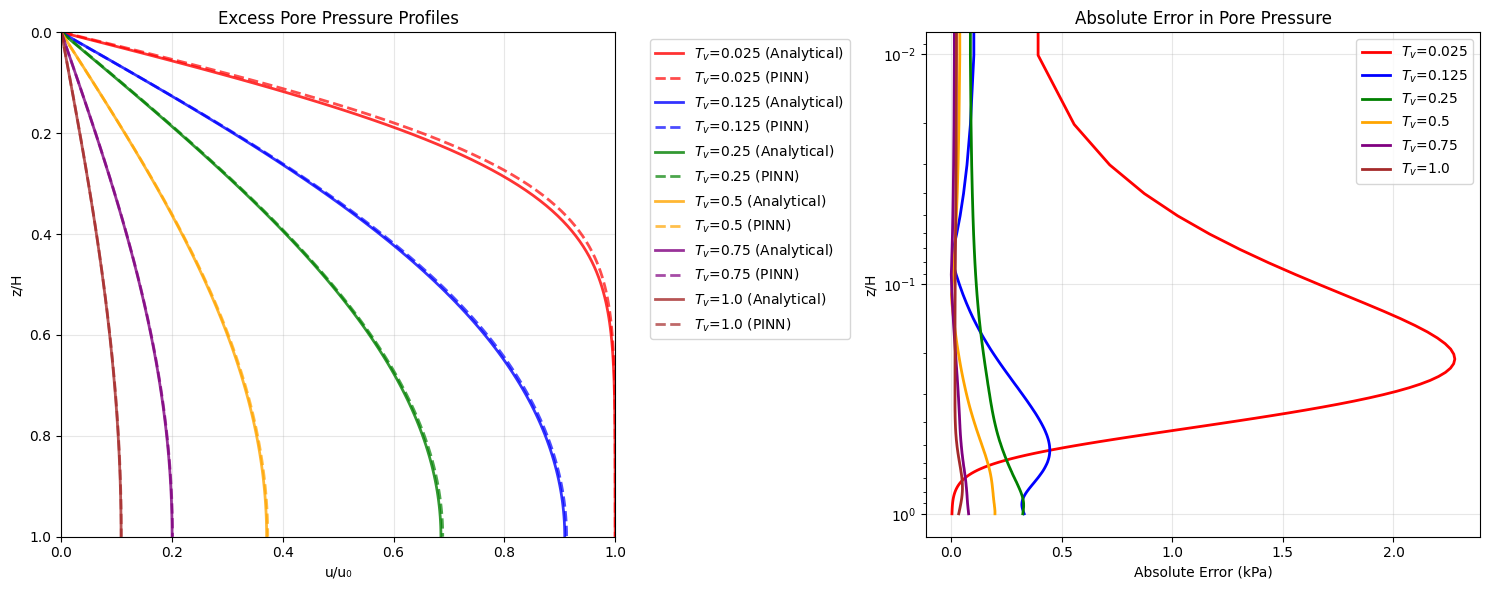

In [6]:
Tv_values, z_normalized = create_plots(model, H, T, cv, u0)

## Point-wise comparison

In [7]:
comprehensive_analysis(model, H, T, cv, u0)


Point-wise Comparison:
Time     Depth    Analytical   PINN         Error        Rel Error % 
---------------------------------------------------------------------------


0.10     0.00     0.0000       -0.1473      0.1473       1473207473.75
0.10     0.25     42.3759      42.7679      0.3919       0.92        
0.10     0.50     73.5651      74.1243      0.5591       0.76        
0.10     0.75     90.1279      90.4945      0.3666       0.41        
0.10     1.00     94.9305      95.1694      0.2389       0.25        
0.25     0.00     0.0000       0.0838       0.0838       838041305.54
0.25     0.25     26.4461      26.6061      0.1600       0.60        
0.25     0.50     48.7013      48.9256      0.2243       0.46        
0.25     0.75     63.4161      63.7168      0.3008       0.47        
0.25     1.00     68.5446      68.8684      0.3239       0.47        
0.50     0.00     0.0000       -0.0426      0.0426       426492691.04
0.50     0.25     14.1899      14.2405      0.0506       0.36        
0.50     0.50     26.2188      26.3569      0.1380       0.53        
0.50     0.75     34.2557      34.4411      0.1854       0.54        
0.50     1.00     3

## Training history and degree of consolidation


 Creating training analysis plots...
Computing degree of consolidation curves...


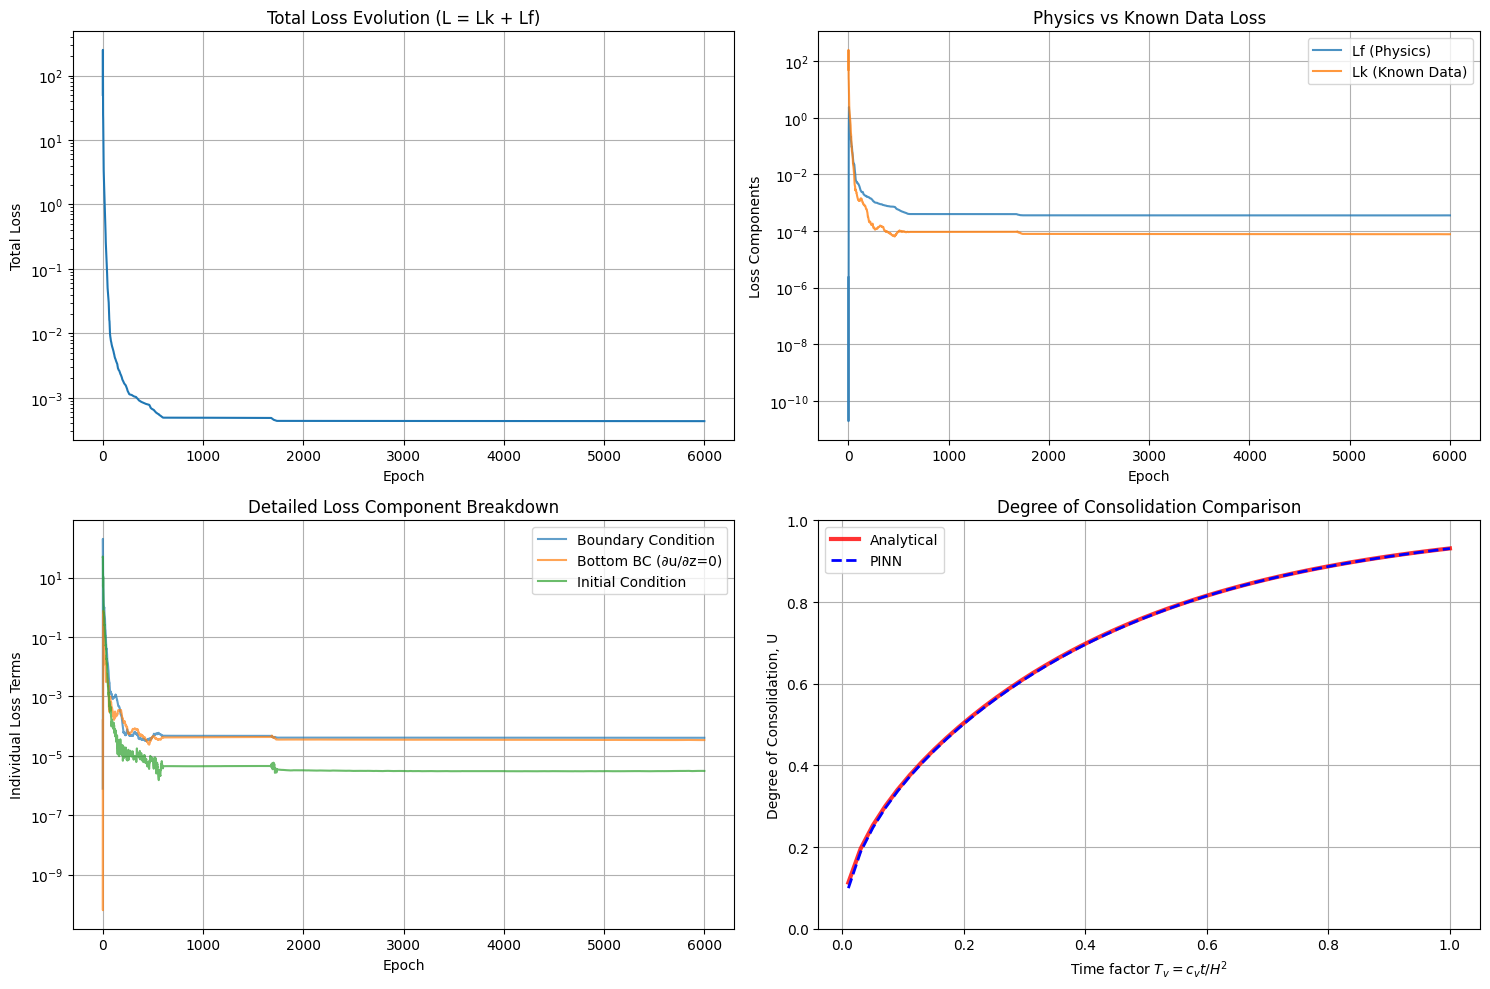

FINAL RESULTS SUMMARY
Final Total Loss: 0.00043388
Final Physics Loss (Lf): 0.00035674
Final Known Data Loss (Lk): 0.00007713


In [8]:
show_training_plots(losses, loss_components)

final_loss = loss_components['total'][-1]
final_lf = loss_components['Lf'][-1]
final_lk = loss_components['Lk'][-1]

print("="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"Final Total Loss: {final_loss:.8f}")
print(f"Final Physics Loss (Lf): {final_lf:.8f}")
print(f"Final Known Data Loss (Lk): {final_lk:.8f}")